# NBA 勝負預測與投注策略 — 實驗程式碼

本 notebook 為論文《基於機器學習之 NBA 勝負預測：從預測準度到投注報酬》之**實驗程式碼**，對應論文第三、四章之完整實驗流程。

流程分為兩階段：
1. **勝負預測階段**（第 4.2 節）：建構五組資料集 a / a′ / b / c / d，比較七個模型之 Acc / AUC，並輸出詳細分類指標與特徵重要性。
2. **投注模擬階段**（第 4.3 節）：於 dataset c 上，以四種策略（Exp1–Exp4）逐步疊加 EV/Kelly、雙視角共識與分數帶機制，評估 ROI。

> 執行環境：Python 3、scikit-learn、xgboost。資料檔（`nba_games_331.csv`、`cbs_moneyline_2024_2026_331.csv`）置於 data/ 子目錄，請從專案根目錄啟動 Jupyter。

In [1]:
# === 匯入套件與全域設定 ===
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, RidgeClassifier, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             precision_score, recall_score, f1_score)
from scipy.special import expit
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# ---- 全域超參數（集中於此，便於檢視與調整）----
RANDOM_STATE = 42
N_SPLITS     = 3              # TimeSeriesSplit 折數（特徵選擇與機率校準共用）

# Elo 動態實力指標
ELO_K     = 20               # 單場對 Elo 之更新權重
ELO_DECAY = 0.25             # 賽季衰減係數（向 1500 回歸之比例）
ELO_BASE  = 1500             # Elo 基準分數

# 投注策略
INIT_BANKROLL  = 10000       # 初始資金
KELLY_ALPHA    = 0.05        # Fractional Kelly 縮放係數（1/20 Kelly）
CONF           = 0.51        # 雙視角共識門檻
BAND_L, BAND_U = 0.40, 0.60  # 分數帶上下界（由開發集 Stacking Classifier 掃描選定）

# 資料檔名
NBA_GAMES_CSV = 'data/nba_games_331.csv'
ODDS_CSV      = 'data/cbs_moneyline_2024_2026_331.csv'

split = TimeSeriesSplit(n_splits=N_SPLITS)
print('套件與設定載入完成')

套件與設定載入完成


## 1. 資料載入與清理

讀取 Basketball Reference 抓取之逐場資料（2016--17 至 2025--26 共十個賽季）。將每支球隊「下一場」之勝負上提為預測目標 `target`，並移除含缺失值之欄位。

In [2]:
# === 1. 載入與清理 ===
df = pd.read_csv(NBA_GAMES_CSV, index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 移除多餘欄位
cols_to_drop = ['mp.1', 'mp_opp.1', 'index_opp']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 將「下一場」勝負上提為預測目標（無下一場者標記為 2，稍後濾除）
df['target'] = df.groupby('team')['won'].shift(-1)
df['target'] = df['target'].fillna(2).astype(int)

# 移除含缺失值之欄位
nulls = pd.isnull(df).sum()
nulls = nulls[nulls > 0]
valid_columns = df.columns[~df.columns.isin(nulls.index)]
df = df[valid_columns].copy()
print(f'資料載入完成：{df.shape[0]} 筆紀錄，{df.shape[1]} 欄')

資料載入完成：27960 筆紀錄，136 欄


## 2. 特徵工程

於原始單場數據之上，建構本研究之新計算特徵（共 48 個），分為四類：團隊爆發力指標、Elo 動態實力指標、賽程與旅行特徵，以及全特徵之近 5 / 10 場滾動平均。最後將同一場比賽之主、客兩隊特徵對戰合併（`_x` 為主角球隊、`_y` 為對手）。


In [3]:
# === 2.1 團隊爆發力指標（取整隊各項統計最高值，融合不同球員之最佳表現）===
# Game Score（單場效率綜合指標）
df['gmsc_max'] = (
    df['pts_max'] + 0.4 * df['fg_max'] - 0.7 * df['fga_max'] -
    0.4 * (df['fta_max'] - df['ft_max']) + 0.7 * df['orb_max'] +
    0.3 * df['drb_max'] + df['stl_max'] + 0.7 * df['ast_max'] +
    0.7 * df['blk_max'] - 0.4 * df['pf_max'] - df['tov_max']
)
# 簡化版 PER（每分鐘效率）
df['per_max'] = (
    df['pts_max'] + df['ast_max'] + df['trb_max'] + df['stl_max'] + df['blk_max'] -
    (df['fga_max'] - df['fg_max']) - (df['fta_max'] - df['ft_max']) - df['tov_max']
) / 240
print('團隊爆發力指標（gmsc_max / per_max）已建立')

團隊爆發力指標（gmsc_max / per_max）已建立


In [4]:
# === 2.2 Elo 動態實力指標（含賽季衰減）===
# 以逐日結算模擬時間流；每個新賽季開始時將 Elo 向 1500 回歸以反映陣容變動。
elo_dict = {team: ELO_BASE for team in df['team'].unique()}
df['elo'] = 0.0
df['elo_opp'] = 0.0
current_season = None

for date in df['date'].unique():
    daily_games = df[df['date'] == date]
    game_season = daily_games['season'].iloc[0]

    # 賽季切換：向均值回歸
    if current_season is not None and game_season != current_season:
        for team in elo_dict:
            elo_dict[team] = elo_dict[team] * (1 - ELO_DECAY) + ELO_BASE * ELO_DECAY
    current_season = game_season

    # 逐場計算賽前 Elo 並結算
    daily_updates = {}
    for idx, row in daily_games.iterrows():
        team, opp, won = row['team'], row['team_opp'], row['won']
        team_pre, opp_pre = elo_dict[team], elo_dict[opp]
        df.loc[idx, 'elo'] = team_pre
        df.loc[idx, 'elo_opp'] = opp_pre
        expected = 1 / (1 + 10 ** ((opp_pre - team_pre) / 400))
        daily_updates[team] = team_pre + ELO_K * (int(won) - expected)
    for t, new_elo in daily_updates.items():
        elo_dict[t] = new_elo

df['elo_diff'] = df['elo'] - df['elo_opp']
print(f"Elo 已注入；elo 範圍 {df['elo'].min():.1f} ~ {df['elo'].max():.1f}")

Elo 已注入；elo 範圍 1215.5 ~ 1825.8


In [5]:
# === 2.3 賽程、休息與旅行特徵（僅用今天以前之資訊，避免洩漏）===
df = df.sort_values(['team', 'date']).reset_index(drop=True)

# 休息天數與密集賽程旗標
df['days_rest'] = df.groupby('team')['date'].diff().dt.days.fillna(7)
df['is_b2b']  = (df['days_rest'] == 1).astype(int)
df['is_3in4'] = df.groupby('team')['date'].transform(
    lambda x: x.diff().dt.days.rolling(3, min_periods=1).sum() <= 4).astype(int)
df['is_4in6'] = df.groupby('team')['date'].transform(
    lambda x: x.diff().dt.days.rolling(4, min_periods=1).sum() <= 6).astype(int)

# 過去 N 天比賽數
for window in [5, 7, 10]:
    tmp = df.set_index('date').groupby('team')['won'].rolling(f'{window}D').count()
    df[f'games_last_{window}d'] = tmp.reset_index(level=0, drop=True).values - 1
    df[f'games_last_{window}d'] = df[f'games_last_{window}d'].clip(lower=0)

# 連續主／客場 streak
def compute_streak(series):
    grp = (series != series.shift()).cumsum()
    return series.groupby(grp).cumcount() + 1

df['home_streak']  = df.groupby('team')['home'].transform(lambda s: compute_streak(s) * s).astype(int)
df['away_streak']  = df.groupby('team')['home'].transform(lambda s: compute_streak(1 - s) * (1 - s)).astype(int)
df['is_long_road'] = (df['away_streak'] >= 4).astype(int)

# 旅行距離（Haversine, km）與時區變化
arena_coords = {
    'ATL':(33.7573,-84.3963),  'BOS':(42.3662,-71.0621), 'BRK':(40.6827,-73.9754),
    'CHO':(35.2251,-80.8392),  'CHI':(41.8807,-87.6742), 'CLE':(41.4965,-81.6882),
    'DAL':(32.7905,-96.8104),  'DEN':(39.7487,-105.0077),'DET':(42.3410,-83.0550),
    'GSW':(37.7680,-122.3877), 'HOU':(29.7508,-95.3621), 'IND':(39.7640,-86.1555),
    'LAC':(34.0430,-118.2673), 'LAL':(34.0430,-118.2673),'MEM':(35.1382,-90.0505),
    'MIA':(25.7814,-80.1870),  'MIL':(43.0451,-87.9172), 'MIN':(44.9795,-93.2760),
    'NOP':(29.9490,-90.0821),  'NYK':(40.7505,-73.9934), 'OKC':(35.4634,-97.5151),
    'ORL':(28.5392,-81.3839),  'PHI':(39.9012,-75.1720), 'PHO':(33.4457,-112.0712),
    'POR':(45.5316,-122.6668), 'SAC':(38.6490,-121.5180),'SAS':(29.4270,-98.4375),
    'TOR':(43.6435,-79.3791),  'UTA':(40.7683,-111.9011),'WAS':(38.8981,-77.0209),
}
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1); dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r)*np.cos(lat2r)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['game_lat'] = np.where(df['home']==1,
    df['team'].map(lambda t: arena_coords.get(t, (0,0))[0]),
    df['team_opp'].map(lambda t: arena_coords.get(t, (0,0))[0]))
df['game_lon'] = np.where(df['home']==1,
    df['team'].map(lambda t: arena_coords.get(t, (0,0))[1]),
    df['team_opp'].map(lambda t: arena_coords.get(t, (0,0))[1]))
df['prev_lat'] = df.groupby('team')['game_lat'].shift(1)
df['prev_lon'] = df.groupby('team')['game_lon'].shift(1)
df['travel_km'] = haversine_km(df['prev_lat'], df['prev_lon'],
                               df['game_lat'],  df['game_lon']).fillna(0)
df['game_tz'] = (df['game_lon'] / 15).round()
df['prev_tz'] = (df['prev_lon'] / 15).round()
df['timezone_change'] = (df['game_tz'] - df['prev_tz']).fillna(0)
df['cross_timezone']  = (df['timezone_change'].abs() >= 2).astype(int)
df = df.drop(columns=['game_lat','game_lon','prev_lat','prev_lon','game_tz','prev_tz'])

# 賽程類原始特徵（不參與滾動；elo 亦保留原值）
schedule_raw_cols = [
    'days_rest','is_b2b','is_3in4','is_4in6',
    'games_last_5d','games_last_7d','games_last_10d',
    'home_streak','away_streak','is_long_road',
    'travel_km','timezone_change','cross_timezone', 'elo',
]
schedule_raw_cols = [c for c in schedule_raw_cols if c in df.columns]
print(f'賽程／旅行特徵已注入（{len(schedule_raw_cols)} 個原始特徵不參與滾動）')

賽程／旅行特徵已注入（14 個原始特徵不參與滾動）


In [6]:
# === 2.4 近 5 / 10 場滾動平均（依球隊、賽季分組，逐季重置）===
removed_columns = ['season','date','won','target','team','team_opp'] + schedule_raw_cols
selected_columns = df.columns[~df.columns.isin(removed_columns)]
df_to_roll = df[list(selected_columns) + ['won','team','season']]

def find_team_averages(team, window):
    numeric_cols = team.select_dtypes(include=[np.number]).columns
    return team[numeric_cols].rolling(window).mean()

df_rolling_10 = df_to_roll.groupby(['team','season'], group_keys=False).apply(lambda g: find_team_averages(g, 10))
df_rolling_10.columns = [f'{c}_10' for c in df_rolling_10.columns]

df_rolling_5 = df_to_roll.groupby(['team','season'], group_keys=False).apply(lambda g: find_team_averages(g, 5))
df_rolling_5.columns = [f'{c}_5' for c in df_rolling_5.columns]

df = pd.concat([df, df_rolling_10, df_rolling_5], axis=1)
df = df.dropna()

rolling_cols = list(df_rolling_10.columns) + list(df_rolling_5.columns)
schedule_transfer_cols = schedule_raw_cols.copy()
print(f'滾動特徵 {len(rolling_cols)} 欄已建立')

滾動特徵 270 欄已建立


In [7]:
# === 2.5 對戰合併（將同場主、客兩隊之特徵併為一列）===
# pandas 自動以 _x（主角球隊）/ _y（對手）後綴解決同名衝突。
def add_next(col_name):
    return df.groupby('team', group_keys=False).apply(lambda x: x[col_name].shift(-1))

df['date_next']     = add_next('date')
df['home_next']     = add_next('home')
df['team_opp_next'] = add_next('team_opp')

merge_cols = rolling_cols + schedule_transfer_cols + ['team_opp_next', 'date_next', 'team']
full = df.merge(
    df[merge_cols],
    left_on=['team', 'date_next'],
    right_on=['team_opp_next', 'date_next'],
)
full = full.dropna()
print(f'對戰合併完成：full = {full.shape}')

對戰合併完成：full = (24842, 713)


## 3. 訓練 / 開發 / 樣本外切分

嚴格依時間切分以避免資料洩漏：訓練集為 2016--17 至 2023--24（season < 2025），開發集為 2024--25（season = 2025），樣本外測試集為 2025--26 至 2026/3/31（season = 2026）。特徵選擇所需之交叉驗證採用 `TimeSeriesSplit`。

In [8]:
# === 3. 切分訓練 / 測試集 ===
train_data = full[full['season'] < 2025].copy()
test_data  = full[full['season'] >= 2025].copy()

# 2025--26 賽季僅保留 2026/3/31 以前
test_data['date'] = pd.to_datetime(test_data['date'])
test_data = test_data[~((test_data['season'] == 2026) & (test_data['date'] >= pd.Timestamp('2026-04-01')))]

# 濾除無下一場者（target == 2）
train_data = train_data[train_data['target'] != 2]
test_data  = test_data[test_data['target'] != 2]

# 以主隊視角去重後之獨立比賽數（勝負預測評估集）
_te = test_data[test_data['home_next'] == 1]
print(f'訓練集 {len(train_data)} 列；測試集 {len(test_data)} 列')
print(f'測試集去重後獨立比賽：合併 {len(_te)} 場'
      f'（2024-25 {int((_te.season==2025).sum())} / 2025-26 {int((_te.season==2026).sum())}）')

訓練集 20514 列；測試集 4328 列
測試集去重後獨立比賽：合併 2165 場（2024-25 1181 / 2025-26 984）


## 4. 五組資料集（a / a′ / b / c / d）

於完整特徵池之上建構五組資料集，涵蓋特徵工程消融（a vs a′）與三類特徵選擇器之比較：

| 代號 | 內容 | 特徵選擇方法 |
|------|------|--------------|
| a | 僅原始單場數據與其滾動平均（排除全部新計算特徵） | 對照組（baseline） |
| a′ | 含全部特徵（新特徵全保留，不做選擇） | — |
| b | 對 a′ 做 Pearson 相關係數篩選 | 過濾式（Filter） |
| c | 對 a′ 做 RFECV 遞迴特徵消除（基底 Logistic Regression） | 包裹式（Wrapper） |
| d | 對 a′ 做 ElasticNetCV 嵌入式選擇（L1+L2 正則化） | 嵌入式（Embedded） |

所有候選特徵先以 MinMaxScaler 縮放（於訓練集 fit、測試集套用），再進行各選擇器之計算。

In [9]:
# === 4.1 候選特徵池 + 新計算特徵辨識 ===
numeric_cols = full.select_dtypes(include=['number']).columns
removed_meta_cols = (list(full.columns[full.dtypes == 'object'])
                     + ['season', 'date', 'won', 'target', 'team', 'team_opp'])
all_features = [c for c in numeric_cols if c not in removed_meta_cols]

# 新計算特徵之辨識關鍵字（dataset a 會排除這些）
new_feature_patterns = [
    'elo', 'gmsc', 'per_max', 'days_rest',
    'is_b2b', 'is_3in4', 'is_4in6', 'games_last',
    'home_streak', 'away_streak', 'is_long_road',
    'travel_km', 'timezone_change', 'cross_timezone',
]
def is_new_feature(col_name):
    c = col_name.lower()
    return any(kw in c for kw in new_feature_patterns)

n_new = sum(1 for c in all_features if is_new_feature(c))
print(f'候選特徵總數：{len(all_features)}'
      f'（原始/滾動 {len(all_features)-n_new}，新計算特徵 {n_new}）')

候選特徵總數：703（原始/滾動 655，新計算特徵 48）


In [10]:
# === 4.2 特徵縮放 + dataset a / a′ ===
scaler_all = MinMaxScaler()
train_data[all_features] = scaler_all.fit_transform(train_data[all_features])
test_data[all_features]  = scaler_all.transform(test_data[all_features])

y_train = train_data['target'].values
y_test  = test_data['target'].values

datasets = {}
datasets['a']  = [c for c in all_features if not is_new_feature(c)]   # 排除新特徵
datasets["a'"] = list(all_features)                                   # 全特徵
print(f"dataset a  : {len(datasets['a'])} 特徵")
print(f"dataset a' : {len(datasets[chr(34)+chr(97)+chr(39)+chr(34)]) if False else len(datasets['a' + chr(39)])} 特徵")

dataset a  : 655 特徵
dataset a' : 703 特徵


In [11]:
# === 4.3 dataset b：Pearson 相關係數篩選 ===
pearson_corr = {}
for col in all_features:
    r = np.corrcoef(train_data[col].values, y_train)[0, 1]
    pearson_corr[col] = abs(r) if not np.isnan(r) else 0.0

PEARSON_THRESHOLD = 0.03
corr_series = pd.Series(pearson_corr).sort_values(ascending=False)
selected_by_thresh = corr_series[corr_series >= PEARSON_THRESHOLD].index.tolist()
if len(selected_by_thresh) < 30:                 
    selected_by_thresh = corr_series.head(30).index.tolist()

datasets['b'] = selected_by_thresh
print(f"dataset b (Pearson |r| >= {PEARSON_THRESHOLD}): {len(datasets['b'])} 特徵")

dataset b (Pearson |r| >= 0.03): 389 特徵


In [12]:
# === 4.4 dataset c：RFECV 遞迴特徵消除（基底 Logistic Regression）===
base_est_rfecv = LogisticRegression(
    penalty='l2', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
rfecv = RFECV(
    estimator=base_est_rfecv, step=5, cv=split,
    scoring='roc_auc', min_features_to_select=10, n_jobs=-1)
rfecv.fit(train_data[all_features], y_train)

datasets['c'] = [c for c, keep in zip(all_features, rfecv.support_) if keep]
rfecv_obj = rfecv
print(f"dataset c (RFECV): {len(datasets['c'])} 特徵"
      f"（CV 最佳 AUC = {rfecv.cv_results_['mean_test_score'].max():.4f}）")

dataset c (RFECV): 28 特徵（CV 最佳 AUC = 0.7110）


In [13]:
# === 4.5 dataset d：ElasticNetCV 嵌入式特徵選擇 ===
# 以 ElasticNet 正則化之 Logistic Regression 進行嵌入式選擇（係數壓縮至 0 者剔除）。
enet_cv = LogisticRegressionCV(
    penalty='elasticnet', solver='saga',
    l1_ratios=[0.3, 0.5, 0.7, 0.9], Cs=10, cv=split,
    scoring='roc_auc', max_iter=3000, random_state=RANDOM_STATE, n_jobs=-1)
enet_cv.fit(train_data[all_features], y_train)

coef_abs = np.abs(enet_cv.coef_.ravel())
datasets['d'] = [c for c, keep in zip(all_features, coef_abs > 1e-8) if keep]
if len(datasets['d']) < 15:                       
    top_idx = np.argsort(coef_abs)[::-1][:30]
    datasets['d'] = [all_features[i] for i in top_idx]
print(f"dataset d (ElasticNetCV): {len(datasets['d'])} 特徵"
      f"（最佳 C={enet_cv.C_[0]:.4g}, l1_ratio={enet_cv.l1_ratio_[0]:.2f}）")

print('\n五組資料集特徵數：')
for k in ['a', "a'", 'b', 'c', 'd']:
    print(f"  dataset {k:<3}: {len(datasets[k]):>4}")

dataset d (ElasticNetCV): 232 特徵（最佳 C=0.04642, l1_ratio=0.30）

五組資料集特徵數：
  dataset a  :  655
  dataset a' :  703
  dataset b  :  389
  dataset c  :   28
  dataset d  :  232


## 5. 勝負預測實驗

於五組資料集上評估七個模型（Lasso、Logistic、Ridge、Linear SVM、Random Forest、XGBoost、Stacking Classifier）。評估集以主隊視角去重，報告 2024--25、2025--26 及合併之 Accuracy 與 AUC。Ridge 與 SVM 無 `predict_proba`，以 `decision_function` 經 sigmoid 轉換取得機率。

In [14]:
# === 5.1 實驗 5：五組資料集 × 七個模型之 Acc / AUC ===
def build_models():
    base_estimators = [
        ('lr',    LogisticRegression(penalty='l2', max_iter=1000, random_state=RANDOM_STATE)),
        ('ridge', RidgeClassifier(random_state=RANDOM_STATE)),
        ('rf',    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)),
    ]
    return {
        'Lasso (L1 Logistic)': LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE),
        'Logistic Regression': LogisticRegression(penalty='l2', max_iter=1000, random_state=RANDOM_STATE),
        'Ridge Regression':    RidgeClassifier(random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        'SVM (Linear)':        SVC(kernel='linear', random_state=RANDOM_STATE),
        'Stacking Classifier': StackingClassifier(estimators=base_estimators,
                                                  final_estimator=LogisticRegression()),
    }

def get_proba(model, model_name, X):
    if model_name in ('Ridge Regression', 'SVM (Linear)'):
        return expit(model.decision_function(X))
    return model.predict_proba(X)[:, 1]

dataset_order = ['a', "a'", 'b', 'c', 'd']
model_order = ['Logistic Regression', 'Ridge Regression', 'Lasso (L1 Logistic)',
               'SVM (Linear)', 'Random Forest', 'XGBoost', 'Stacking Classifier']

home_mask = (test_data['home_next'] == 1).values   # 主隊視角去重遮罩
mask_25 = (test_data.loc[home_mask, 'season'] == 2025).values
mask_26 = (test_data.loc[home_mask, 'season'] == 2026).values

exp5_rows = []
predictions_store = {}        # 供實驗 7 重用各模型之預測

for ds_key in dataset_order:
    feats = datasets[ds_key]
    for model_name, model in build_models().items():
        model.fit(train_data[feats], y_train)
        proba_full = get_proba(model, model_name, test_data[feats])
        pred_full  = (proba_full >= 0.5).astype(int)

        proba_eval = proba_full[home_mask]
        pred_eval  = pred_full[home_mask]
        y_eval     = y_test[home_mask]

        acc_all = accuracy_score(y_eval, pred_eval)
        auc_all = roc_auc_score(y_eval, proba_eval)
        acc_25  = accuracy_score(y_eval[mask_25], pred_eval[mask_25])
        acc_26  = accuracy_score(y_eval[mask_26], pred_eval[mask_26])

        exp5_rows.append({'Dataset': ds_key, 'Model': model_name,
                          'Acc_2425': round(acc_25, 4), 'Acc_2526': round(acc_26, 4),
                          'Acc_all': round(acc_all, 4), 'AUC_all': round(auc_all, 4)})
        predictions_store[(ds_key, model_name)] = {'pred_eval': pred_eval, 'y_eval': y_eval}

exp5_df = pd.DataFrame(exp5_rows)

# 跨模型平均（對應論文發現 1）
avg = exp5_df.groupby('Dataset')[['Acc_2425', 'Acc_2526', 'Acc_all']].mean().reindex(dataset_order).round(4)
print('各資料集跨模型平均 Acc：')
print(avg.to_string())
print(f"\na → a' 合併 Acc：{avg.loc['a','Acc_all']:.4f} → {avg.loc[chr(97)+chr(39),'Acc_all']:.4f}"
      f"（+{(avg.loc['a'+chr(39),'Acc_all']-avg.loc['a','Acc_all'])*100:.2f} pp）")

# 單一最高 Acc 組合（對應論文 67.62%）
best = exp5_df.loc[exp5_df['Acc_all'].idxmax()]
print(f"單一最高 Acc：{best['Model']} + dataset {best['Dataset']} = {best['Acc_all']*100:.2f}%")
exp5_df.to_csv('exp5_dataset_model_comparison.csv', index=False)

各資料集跨模型平均 Acc：
         Acc_2425  Acc_2526  Acc_all
Dataset                             
a          0.6364    0.6298   0.6334
a'         0.6590    0.6495   0.6547
b          0.6537    0.6514   0.6527
c          0.6580    0.6536   0.6560
d          0.6500    0.6554   0.6524

a → a' 合併 Acc：0.6334 → 0.6547（+2.13 pp）
單一最高 Acc：Stacking Classifier + dataset a' = 67.62%


In [15]:
# === 5.2 完整結果表：五組資料集 × 七個模型之 Accuracy（論文表 7）===

try:
    _exp5 = exp5_df.copy()
except NameError:
    _exp5 = pd.read_csv('exp5_dataset_model_comparison.csv')

_DS = ['a', "a'", 'b', 'c', 'd']
_MODELS = ['Lasso (L1 Logistic)', 'Logistic Regression', 'Ridge Regression',
           'Random Forest', 'XGBoost', 'SVM (Linear)', 'Stacking Classifier']

print('勝負預測階段完整結果：五組資料集 × 七個模型之 Accuracy（論文表 7）')
print('=' * 72)
print(f"{'Dataset':<9}{'Model':<22}{'ACC (24-25)':>13}{'ACC (25-26)':>13}{'ACC (all)':>12}")
print('-' * 72)
for ds in _DS:
    for i, m in enumerate(_MODELS):
        r = _exp5[(_exp5['Dataset'] == ds) & (_exp5['Model'] == m)].iloc[0]
        print(f"{(ds if i == 0 else ''):<9}{m:<22}"
              f"{r['Acc_2425']:>13.4f}{r['Acc_2526']:>13.4f}{r['Acc_all']:>12.4f}")
    print('-' * 72)

# 同時提供 DataFrame 形式（依論文表 7 之列序排列）
exp5_full_table = (_exp5.set_index(['Dataset', 'Model'])
                   .loc[[(d, m) for d in _DS for m in _MODELS],
                        ['Acc_2425', 'Acc_2526', 'Acc_all']]
                   .rename(columns={'Acc_2425': 'ACC (24-25)',
                                    'Acc_2526': 'ACC (25-26)',
                                    'Acc_all':  'ACC (all)'}))
exp5_full_table

勝負預測階段完整結果：五組資料集 × 七個模型之 Accuracy（論文表 7）
Dataset  Model                   ACC (24-25)  ACC (25-26)   ACC (all)
------------------------------------------------------------------------
a        Lasso (L1 Logistic)          0.6461       0.6413      0.6439
         Logistic Regression          0.6384       0.6402      0.6393
         Ridge Regression             0.6410       0.6280      0.6351
         Random Forest                0.6198       0.6098      0.6152
         XGBoost                      0.6063       0.6077      0.6069
         SVM (Linear)                 0.6511       0.6250      0.6393
         Stacking Classifier          0.6520       0.6565      0.6540
------------------------------------------------------------------------
a'       Lasso (L1 Logistic)          0.6638       0.6626      0.6633
         Logistic Regression          0.6664       0.6606      0.6637
         Ridge Regression             0.6638       0.6514      0.6582
         Random Forest                0.644

ACC (24-25)  ACC (25-26)  ACC (all)
Dataset Model                                                   
a       Lasso (L1 Logistic)       0.6461       0.6413     0.6439
        Logistic Regression       0.6384       0.6402     0.6393
        Ridge Regression          0.6410       0.6280     0.6351
        Random Forest             0.6198       0.6098     0.6152
        XGBoost                   0.6063       0.6077     0.6069
        SVM (Linear)              0.6511       0.6250     0.6393
        Stacking Classifier       0.6520       0.6565     0.6540
a'      Lasso (L1 Logistic)       0.6638       0.6626     0.6633
        Logistic Regression       0.6664       0.6606     0.6637
        Ridge Regression          0.6638       0.6514     0.6582
        Random Forest             0.6444       0.6311     0.6383
        XGBoost                   0.6342       0.6250     0.6300
        SVM (Linear)              0.6622       0.6423     0.6531
        Stacking Classifier       0.6782       0.6738     0.6762
b       Lasso (L1 Logistic)       0.6681       0.6626     0.6656
        Logistic Regression       0.6664       0.6565     0.6619
        Ridge Regression          0.6596       0.6443     0.6527
        Random Forest             0.6367       0.6423     0.6393
        XGBoost                   0.6181       0.6270     0.6222
        SVM (Linear)              0.6605       0.6524     0.6568
        Stacking Classifier       0.6664       0.6748     0.6702
c       Lasso (L1 Logistic)       0.6647       0.6565     0.6610
        Logistic Regression       0.6638       0.6535     0.6591
        Ridge Regression          0.6655       0.6535     0.6600
        Random Forest             0.6486       0.6565     0.6522
        XGBoost                   0.6325       0.6372     0.6346
        SVM (Linear)              0.6638       0.6545     0.6596
        Stacking Classifier       0.6672       0.6636     0.6656
d       Lasso (L1 Logistic)       0.6588       0.6677     0.6628
        Logistic Regression       0.6588       0.6667     0.6624
        Ridge Regression          0.6588       0.6555     0.6573
        Random Forest             0.6334       0.6413     0.6370
        XGBoost                   0.6224       0.6341     0.6277
        SVM (Linear)              0.6554       0.6494     0.6527
        Stacking Classifier       0.6622       0.6728     0.6670

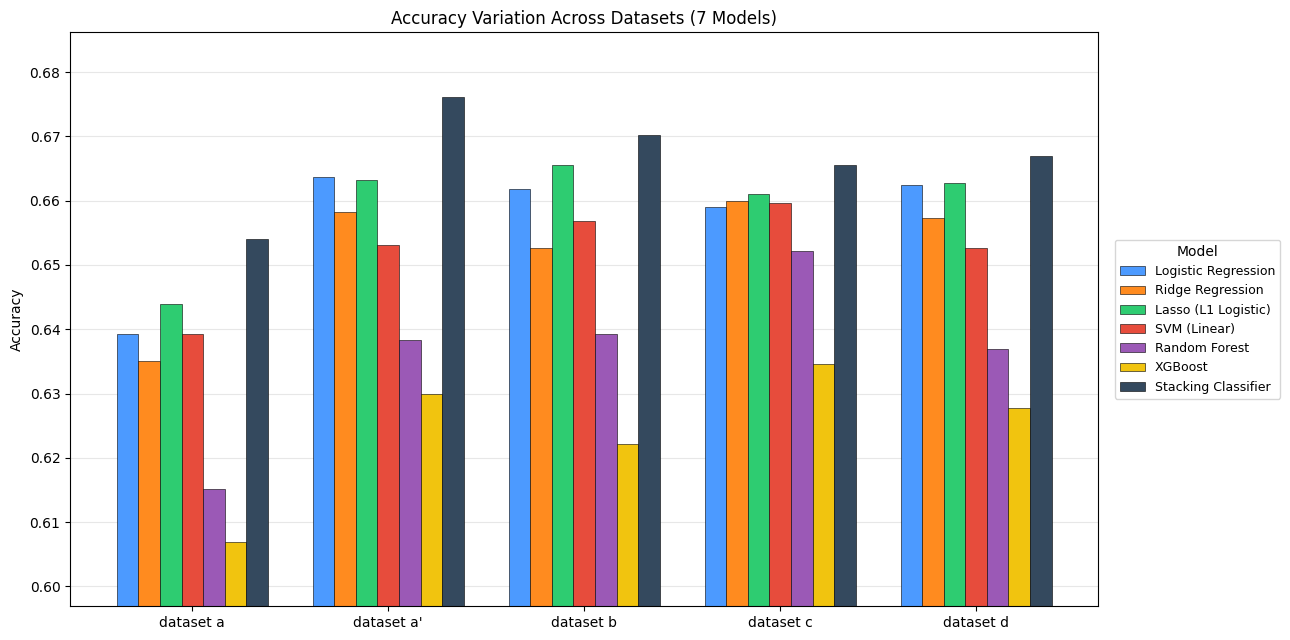

已儲存 exp6_grouped_bar_accuracy.png


In [16]:
# === 5.3 實驗 6：跨資料集 × 模型之 Accuracy 分組長條圖 ===
fig, ax = plt.subplots(figsize=(13, 6.5))
pivot = exp5_df.pivot(index='Dataset', columns='Model', values='Acc_all').reindex(
    index=dataset_order, columns=model_order)

n_models = len(model_order)
bar_width = 0.11
x_base = np.arange(len(dataset_order))
palette = ['#4C9AFF', '#FF8B1F', '#2ECC71', '#E74C3C', '#9B59B6', '#F1C40F', '#34495E']

for i, model_name in enumerate(model_order):
    offsets = x_base + (i - n_models/2 + 0.5) * bar_width
    ax.bar(offsets, pivot[model_name].values, bar_width, label=model_name,
           color=palette[i], edgecolor='black', linewidth=0.4)

ax.set_xticks(x_base)
ax.set_xticklabels([f'dataset {k}' for k in dataset_order])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Variation Across Datasets (7 Models)')
ax.set_ylim(max(0.5, pivot.values.min() - 0.01), pivot.values.max() + 0.01)
ax.legend(title='Model', loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('exp6_grouped_bar_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('已儲存 exp6_grouped_bar_accuracy.png')

In [17]:
# === 5.4 實驗 7：dataset c 之各模型詳細分類指標（合併測試集）===
# dataset c 經多準則考量後選為投注實驗之輸入；此處呈現其各模型之 Acc / Precision / Recall / F1。
rows = []
for model_name in model_order:
    rec = predictions_store[('c', model_name)]
    y_eval, pred = rec['y_eval'], rec['pred_eval']
    rows.append({
        'Algorithm':     model_name,
        'Accuracy (%)':  round(accuracy_score(y_eval, pred) * 100, 2),
        'Precision (%)': round(precision_score(y_eval, pred, zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_eval, pred, zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(y_eval, pred, zero_division=0) * 100, 2),
    })
exp7_df = pd.DataFrame(rows).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print('實驗 7 — dataset c 各模型詳細指標（%）：')
print(exp7_df.to_string(index=False))
exp7_df.to_csv('exp7_dataset_c_detailed.csv', index=False)

實驗 7 — dataset c 各模型詳細指標（%）：
          Algorithm  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Stacking Classifier         66.56          66.26       78.63         71.92
Lasso (L1 Logistic)         66.10          65.75       78.80         71.68
   Ridge Regression         66.00          65.74       78.46         71.54
       SVM (Linear)         65.96          65.48       79.30         71.73
Logistic Regression         65.91          65.56       78.80         71.57
      Random Forest         65.22          66.14       74.05         69.87
            XGBoost         63.46          64.92       71.59         68.09


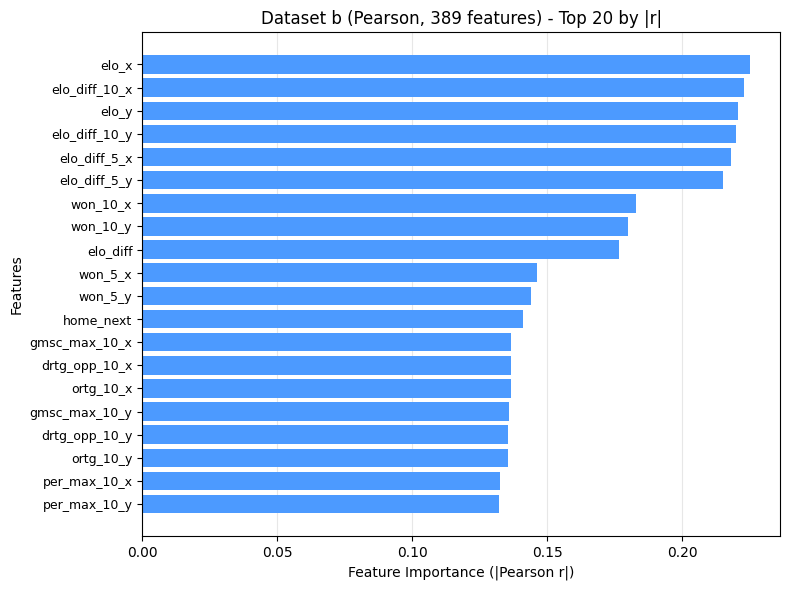

已儲存 top_features_dataset_b.png


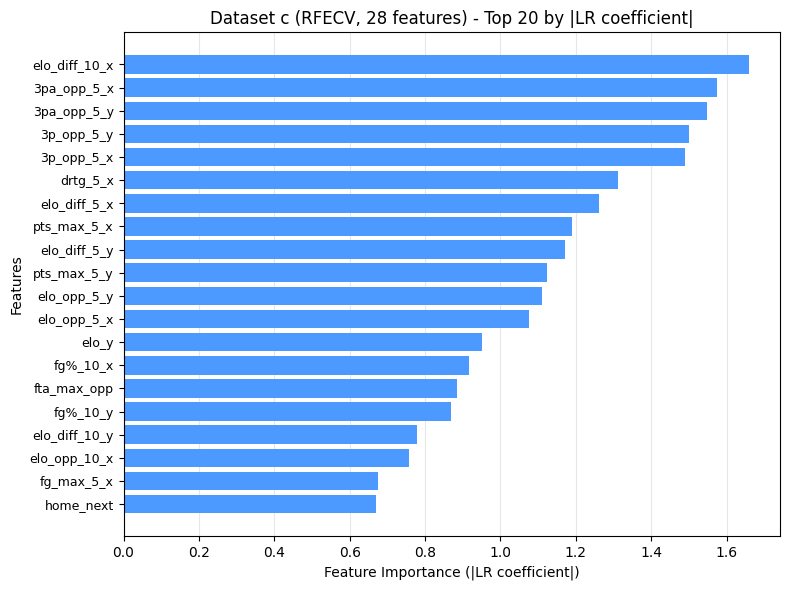

已儲存 top_features_dataset_c.png


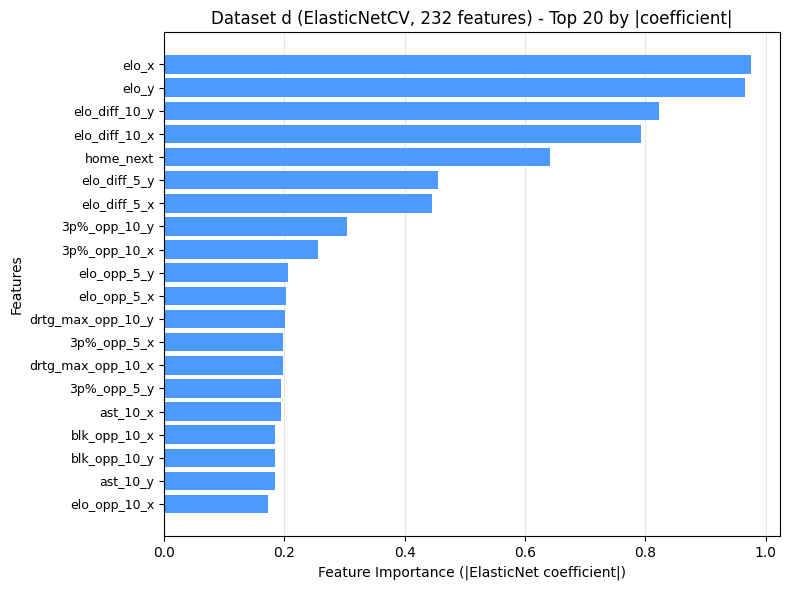

已儲存 top_features_dataset_d.png


In [18]:
# === 5.5 各資料集 Top-20 特徵重要性（給論文 4.2.2 使用）===
# 各資料集以其選擇器之原生分數為重要性：b→|Pearson r|；c→RFECV 基底 LR |coef|；d→ElasticNet |coef|。
importance_scores = {
    'b': pd.Series({c: pearson_corr[c] for c in datasets['b']}),
    'c': pd.Series(np.abs(rfecv_obj.estimator_.coef_.ravel()), index=datasets['c']),
}
_d_full = np.abs(enet_cv.coef_.ravel())
_d_idx = [all_features.index(c) for c in datasets['d']]
importance_scores['d'] = pd.Series(_d_full[_d_idx], index=datasets['d'])

ds_titles = {
    'b': f"Dataset b (Pearson, {len(datasets['b'])} features) - Top 20 by |r|",
    'c': f"Dataset c (RFECV, {len(datasets['c'])} features) - Top 20 by |LR coefficient|",
    'd': f"Dataset d (ElasticNetCV, {len(datasets['d'])} features) - Top 20 by |coefficient|",
}
ds_xlabels = {'b': 'Feature Importance (|Pearson r|)',
              'c': 'Feature Importance (|LR coefficient|)',
              'd': 'Feature Importance (|ElasticNet coefficient|)'}

for ds_key in ['b', 'c', 'd']:
    scores = importance_scores[ds_key]
    n_show = min(20, len(scores))
    top_feats = scores.sort_values(ascending=True).tail(n_show)
    fig, ax = plt.subplots(figsize=(8, max(5, n_show * 0.30)))
    ax.barh(top_feats.index, top_feats.values, color='#4C9AFF', edgecolor='none')
    ax.set_xlabel(ds_xlabels[ds_key]); ax.set_ylabel('Features'); ax.set_title(ds_titles[ds_key])
    ax.tick_params(axis='y', labelsize=9); ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(f'top_features_dataset_{ds_key}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'已儲存 top_features_dataset_{ds_key}.png')

In [19]:
# === 5.6 選定 dataset c 作為投注實驗之輸入 ===
# 依論文第 4.2.5 節：dataset c 之跨模型平均 Acc 與 a′ 統計上實質持平，
# 但僅以 a′ 約 4% 之特徵數，兼具簡約性、過擬合控制與籃球戰術可詮釋性，
# 依簡約性原則（Occam's Razor）獲選進入投注模擬階段。
predictors_advanced = datasets['c']
print(f'投注實驗將使用 dataset c（{len(predictors_advanced)} 個特徵）')

# --- 印出 dataset c 之全部 28 個特徵（對應論文附錄表，依 |LR 係數| 由大至小排序）---
import numpy as _np
try:
    _coef = _np.abs(rfecv_obj.estimator_.coef_.ravel())
    _order = _np.argsort(_coef)[::-1]
    print(f"\ndataset c 之全部 {len(predictors_advanced)} 個特徵"
          f"（依 RFECV 基底 Logistic Regression 係數絕對值排序）：")
    for _rank, _i in enumerate(_order, 1):
        print(f"  #{_rank:<2} {predictors_advanced[_i]:<24} |coef| = {_coef[_i]:.4f}")
    dataset_c_features = pd.DataFrame({
        "rank": range(1, len(_order) + 1),
        "feature": [predictors_advanced[_i] for _i in _order],
        "abs_lr_coef": [round(float(_coef[_i]), 4) for _i in _order],
    })
except NameError:
    # kernel 重啟、rfecv_obj 不在記憶體時，仍印出完整特徵清單（未排序）
    print(f"\ndataset c 之全部 {len(predictors_advanced)} 個特徵（rfecv_obj 不在記憶體，未排序）：")
    for _i, _f in enumerate(predictors_advanced, 1):
        print(f"  {_i:<2} {_f}")
    dataset_c_features = pd.DataFrame({"feature": list(predictors_advanced)})

dataset_c_features

投注實驗將使用 dataset c（28 個特徵）

dataset c 之全部 28 個特徵（依 RFECV 基底 Logistic Regression 係數絕對值排序）：
  #1  elo_diff_10_x            |coef| = 1.6589
  #2  3pa_opp_5_x              |coef| = 1.5753
  #3  3pa_opp_5_y              |coef| = 1.5491
  #4  3p_opp_5_y               |coef| = 1.5002
  #5  3p_opp_5_x               |coef| = 1.4904
  #6  drtg_5_x                 |coef| = 1.3129
  #7  elo_diff_5_x             |coef| = 1.2624
  #8  pts_max_5_x              |coef| = 1.1910
  #9  elo_diff_5_y             |coef| = 1.1705
  #10 pts_max_5_y              |coef| = 1.1224
  #11 elo_opp_5_y              |coef| = 1.1109
  #12 elo_opp_5_x              |coef| = 1.0755
  #13 elo_y                    |coef| = 0.9519
  #14 fg%_10_x                 |coef| = 0.9178
  #15 fta_max_opp              |coef| = 0.8849
  #16 fg%_10_y                 |coef| = 0.8696
  #17 elo_diff_10_y            |coef| = 0.7785
  #18 elo_opp_10_x             |coef| = 0.7568
  #19 fg_max_5_x               |coef| = 0.6740
  #20 home_next   

,rank,feature,abs_lr_coef
0,1,elo_diff_10_x,1.6589
1,2,3pa_opp_5_x,1.5753
2,3,3pa_opp_5_y,1.5491
3,4,3p_opp_5_y,1.5002
4,5,3p_opp_5_x,1.4904
5,6,drtg_5_x,1.3129
6,7,elo_diff_5_x,1.2624
7,8,pts_max_5_x,1.1910
8,9,elo_diff_5_y,1.1705
9,10,pts_max_5_y,1.1224


## 6. 投注模擬實驗

於 dataset c 上進行投注模擬，投注決策為三道篩網之交集：雙視角共識 C(t)、分數帶 B(t)、期望值 E(t)。

In [20]:
# === 6.1 載入 CBS Sports Moneyline 賠率並去水（de-vig）===
odds_raw = pd.read_csv(ODDS_CSV)

# 過濾：僅保留正式賽（移除 All-Star 等）
odds_raw = odds_raw[odds_raw['status'] == 'final'].copy()
odds_raw = odds_raw[~odds_raw['away_team'].str.contains('Stars|Stripes|OGs|World|Rising|Global', na=False)]
odds_raw = odds_raw.dropna(subset=['game_date_local', 'away_ml', 'home_ml'])
odds_raw['date'] = pd.to_datetime(odds_raw['game_date_local'])

# CBS 縮寫 → Basketball-Reference 縮寫
CBS_TO_BBREF = {'BKN':'BRK', 'CHA':'CHO', 'GS':'GSW', 'NO':'NOP', 'NY':'NYK', 'SA':'SAS', 'PHO':'PHO'}
map_abbrev = lambda a: CBS_TO_BBREF.get(a, a)
odds_raw['home_team_bbref'] = odds_raw['home_abbrev'].apply(map_abbrev)
odds_raw['away_team_bbref'] = odds_raw['away_abbrev'].apply(map_abbrev)

# American ML → Decimal odds
def american_to_decimal(ml):
    ml = float(ml)
    if ml > 0:   return 1 + ml / 100
    elif ml < 0: return 1 + 100 / abs(ml)
    return 2.0
odds_raw['home_decimal_odds'] = odds_raw['home_ml'].apply(american_to_decimal)
odds_raw['away_decimal_odds'] = odds_raw['away_ml'].apply(american_to_decimal)

# de-vig：還原為總和為 1 之公平機率，再轉公平賠率
odds_raw['home_implied_prob'] = 1 / odds_raw['home_decimal_odds']
odds_raw['away_implied_prob'] = 1 / odds_raw['away_decimal_odds']
odds_raw['overround'] = odds_raw['home_implied_prob'] + odds_raw['away_implied_prob']
odds_raw['home_fair_prob'] = odds_raw['home_implied_prob'] / odds_raw['overround']
odds_raw['away_fair_prob'] = odds_raw['away_implied_prob'] / odds_raw['overround']
odds_raw['home_fair_odds'] = 1 / odds_raw['home_fair_prob']
odds_raw['away_fair_odds'] = 1 / odds_raw['away_fair_prob']
odds_raw['home_win'] = (odds_raw['home_score'].astype(int) > odds_raw['away_score'].astype(int)).astype(int)

# 賽季標記（依比賽月份）；2025--26 僅保留 3 月底以前
odds_raw['game_season'] = odds_raw['date'].apply(lambda d: d.year + 1 if d.month >= 10 else d.year)
odds_raw = odds_raw[~((odds_raw['game_season'] == 2026) & (odds_raw['date'] >= pd.Timestamp('2026-04-01')))].copy()

odds = odds_raw[[
    'date', 'game_season', 'home_team_bbref', 'away_team_bbref',
    'home_decimal_odds', 'away_decimal_odds',
    'home_fair_prob', 'away_fair_prob', 'home_fair_odds', 'away_fair_odds', 'home_win'
]].rename(columns={'home_team_bbref': 'home_team', 'away_team_bbref': 'away_team'}).copy()

print(f"賠率資料：{len(odds)} 場"
      f"（2024-25 {int((odds.game_season==2025).sum())} / 2025-26 {int((odds.game_season==2026).sum())}）")

# 一致性檢查：與測試集合併後 target 應等於 home_win
_th = test_data[test_data['home_next'] == 1].copy()
_th['date_next'] = pd.to_datetime(_th['date_next'])
_chk = _th.merge(odds, left_on=['date_next', 'team_x'], right_on=['date', 'home_team'], how='inner')
print(f"與測試集成功合併 {len(_chk)} 場；target vs home_win 一致率 {(_chk['target']==_chk['home_win']).mean():.1%}")

賠率資料：2456 場（2024-25 1321 / 2025-26 1135）
與測試集成功合併 2165 場；target vs home_win 一致率 99.7%


In [21]:
# === 6.2 訓練模型 + 選擇性 sigmoid 機率校準 ===
# 依論文第 4.3 節：對 Ridge、Random Forest、XGBoost 三模型之機率施以 sigmoid（Platt）校準，
# 以避免機率極端化影響 Kelly 計算；其餘模型直接採用原始輸出。
base_estimators_new = [
    ('lr',    LogisticRegression(penalty='l2', max_iter=1000, random_state=RANDOM_STATE)),
    ('ridge', RidgeClassifier(random_state=RANDOM_STATE)),
    ('rf',    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)),
]
raw_models = {
    'Lasso (L1 Logistic)': LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(penalty='l2', max_iter=1000, random_state=RANDOM_STATE),
    'Ridge Regression':    RidgeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    'SVM (Linear)':        SVC(kernel='linear', random_state=RANDOM_STATE),
    'Stacking Classifier': StackingClassifier(estimators=base_estimators_new,
                                              final_estimator=LogisticRegression()),
}

# 各模型之機率來源（'raw' = 原始；'cal' = sigmoid 校準）
PROB_SOURCE_MAP = {
    'Lasso (L1 Logistic)': 'raw', 'Logistic Regression': 'raw',
    'Ridge Regression':    'cal', 'Random Forest': 'cal', 'XGBoost': 'cal',
    'SVM (Linear)':        'raw', 'Stacking Classifier': 'cal',
}

uncalibrated_models, calibrated_models = {}, {}
for name, inst in raw_models.items():
    raw_m = clone(inst); raw_m.fit(train_data[predictors_advanced], train_data['target'])
    uncalibrated_models[name] = raw_m
    cal_m = CalibratedClassifierCV(estimator=clone(inst), method='sigmoid', cv=split)
    cal_m.fit(train_data[predictors_advanced], train_data['target'])
    calibrated_models[name] = cal_m
print('七個模型之原始版與校準版已訓練完成')

七個模型之原始版與校準版已訓練完成


In [22]:
# === 6.3 投注函數：Kelly、EV、模擬器、雙視角共識 ===
def kelly_fraction(model_prob, decimal_odds):
    b = decimal_odds - 1
    if b <= 0: return 0.0
    f = (model_prob * b - (1 - model_prob)) / b
    return max(f, 0.0)

def expected_value(model_prob, decimal_odds):
    return model_prob * (decimal_odds - 1) - (1 - model_prob)

def run_unified_simulation(df_odds, model_probs, consensus_mask=None,
                           initial_bankroll=INIT_BANKROLL, kelly_multiplier=KELLY_ALPHA,
                           use_pband=False, pband_lo=BAND_L, pband_hi=BAND_U):
    bankroll = initial_bankroll
    records = []
    for i in range(len(df_odds)):
        row = df_odds.iloc[i]
        pred_home = model_probs[i]; pred_away = 1 - pred_home
        home_fair, away_fair = row['home_fair_odds'], row['away_fair_odds']
        actual_home_win = row['home_win']
        bet_made, profit, bet_amount = False, 0.0, 0.0

        if consensus_mask is not None and not consensus_mask[i]:
            records.append({'bet_made': False, 'profit': 0, 'bankroll': bankroll, 'bet_amount': 0}); continue

        # 分數帶 / 一般方向選擇
        if use_pband:
            side = 'home' if pred_home >= pband_hi else ('away' if pred_home <= pband_lo else None)
        else:
            side = 'home' if pred_home >= 0.50 else 'away'

        if side == 'home':
            if expected_value(pred_home, home_fair) > 0 and kelly_fraction(pred_home, home_fair) > 0:
                bet_amount = min(bankroll * kelly_fraction(pred_home, home_fair) * kelly_multiplier, bankroll)
                bet_made = True
                profit = bet_amount * (home_fair - 1) if actual_home_win == 1 else -bet_amount
        elif side == 'away':
            if expected_value(pred_away, away_fair) > 0 and kelly_fraction(pred_away, away_fair) > 0:
                bet_amount = min(bankroll * kelly_fraction(pred_away, away_fair) * kelly_multiplier, bankroll)
                bet_made = True
                profit = bet_amount * (away_fair - 1) if actual_home_win == 0 else -bet_amount

        bankroll += profit
        records.append({'bet_made': bet_made, 'profit': profit, 'bankroll': bankroll, 'bet_amount': bet_amount})

    rec_df = pd.DataFrame(records)
    bets = rec_df[rec_df['bet_made']]
    if len(bets) == 0:
        return {'total_bets': 0, 'wins': 0, 'losses': 0, 'bet_win_rate': 'N/A',
                'total_profit': 0, 'total_wagered': 0, 'ROI': 0, 'final_bankroll': bankroll,
                'bankroll_series': rec_df['bankroll'].values}
    wins = int((bets['profit'] > 0).sum()); losses = int((bets['profit'] < 0).sum())
    total_wagered = bets['bet_amount'].sum(); total_profit = bets['profit'].sum()
    return {'total_bets': len(bets), 'wins': wins, 'losses': losses,
            'bet_win_rate': f'{wins/len(bets)*100:.1f}%',
            'total_profit': round(total_profit, 2),
            'total_wagered': round(total_wagered, 2),
            'ROI': round(total_profit / total_wagered * 100, 2),
            'final_bankroll': round(bankroll, 2),
            'bankroll_series': rec_df['bankroll'].values}

def build_consensus_data(test_data_full, odds_subset, calibrated_models, predictors,
                         uncalibrated_models, prob_source_map):
    """建立主隊視角與融合機率，並計算雙視角共識遮罩。"""
    test_home_view = test_data_full[test_data_full['home_next'] == 1].copy()
    test_away_view = test_data_full[test_data_full['home_next'] == 0].copy()
    test_home_view['date_next'] = pd.to_datetime(test_home_view['date_next'])
    test_away_view['date_next'] = pd.to_datetime(test_away_view['date_next'])

    test_home_odds = test_home_view.merge(
        odds_subset, left_on=['date_next', 'team_x'], right_on=['date', 'home_team'],
        how='inner').reset_index(drop=True)
    away_lookup = test_home_odds[['date_next', 'away_team']].merge(
        test_away_view, left_on=['date_next', 'away_team'],
        right_on=['date_next', 'team_x'], how='left').reset_index(drop=True)

    # 濾除對手視角缺失之場次
    valid = away_lookup[predictors[0]].notna()
    if (~valid).any():
        away_lookup = away_lookup[valid].reset_index(drop=True)
        test_home_odds = test_home_odds[valid].reset_index(drop=True)

    def _proba(model, X):
        if hasattr(model, 'predict_proba'):
            return model.predict_proba(X)[:, 1]
        return expit(model.decision_function(X))

    p_home_view_dict, p_fused_dict, consensus_mask_dict = {}, {}, {}
    for model_name in calibrated_models:
        src = prob_source_map.get(model_name, 'cal')
        model = uncalibrated_models[model_name] if src == 'raw' else calibrated_models[model_name]
        p_hv = _proba(model, test_home_odds[predictors])
        p_home_from_away = 1 - _proba(model, away_lookup[predictors])
        p_home_view_dict[model_name] = p_hv
        p_fused_dict[model_name] = (p_hv + p_home_from_away) / 2
        home_agree = (p_hv >= CONF) & (p_home_from_away >= CONF)
        away_agree = (p_hv < (1 - CONF)) & (p_home_from_away < (1 - CONF))
        consensus_mask_dict[model_name] = home_agree | away_agree
    return test_home_odds, p_home_view_dict, p_fused_dict, consensus_mask_dict

print('投注函數已定義')

投注函數已定義


In [23]:
# === 6.4 建立雙視角共識資料（分賽季）===
odds_2025 = odds[odds['game_season'] == 2025].copy()
odds_2026 = odds[odds['game_season'] == 2026].copy()

tc_2025, phv_2025, pf_2025, cm_2025 = build_consensus_data(
    test_data, odds_2025, calibrated_models, predictors_advanced, uncalibrated_models, PROB_SOURCE_MAP)
tc_2026, phv_2026, pf_2026, cm_2026 = build_consensus_data(
    test_data, odds_2026, calibrated_models, predictors_advanced, uncalibrated_models, PROB_SOURCE_MAP)
print(f'共識資料：2024-25 {len(tc_2025)} 場，2025-26 {len(tc_2026)} 場')
print(f'分數帶 (L, U) = ({BAND_L}, {BAND_U})（開發集 Stacking Classifier 掃描選定）')

共識資料：2024-25 1165 場，2025-26 995 場
分數帶 (L, U) = (0.4, 0.6)（開發集 Stacking Classifier 掃描選定）


### 四組投注策略（Exp1–Exp4，論文命名）

| 實驗 | 機率來源 | EV+Kelly | 雙視角共識 | 分數帶 |
|------|----------|:--------:|:----------:|:------:|
| Exp1（僅EV/Kelly） | 主隊視角 | ✅ | ❌ | ❌ |
| Exp2（+Cons） | 雙視角融合 | ✅ | ✅ | ❌ |
| Exp3（+Band） | 主隊視角 | ✅ | ❌ | ✅ |
| Exp4（+Cons+Band） | 雙視角融合 | ✅ | ✅ | ✅ |

每組策略分 2024--25（開發集）與 2025--26（樣本外）兩季各自產出結果。

In [24]:
# === 6.5 四策略 × 兩賽季 ===
season_data = {'2024-25': (tc_2025, phv_2025, pf_2025, cm_2025),
               '2025-26': (tc_2026, phv_2026, pf_2026, cm_2026)}
experiments = [
    {'name': 'Exp1 (僅EV/Kelly)', 'prob_key': 'phv', 'use_pband': False, 'use_consensus': False},
    {'name': 'Exp2 (+Cons)',      'prob_key': 'pf',  'use_pband': False, 'use_consensus': True },
    {'name': 'Exp3 (+Band)',      'prob_key': 'phv', 'use_pband': True,  'use_consensus': False},
    {'name': 'Exp4 (+Cons+Band)', 'prob_key': 'pf',  'use_pband': True,  'use_consensus': True },
]

all_results = []
for season_label, (tc, phv, pf, cm) in season_data.items():
    for exp in experiments:
        for model_name in model_order:
            probs  = phv[model_name] if exp['prob_key'] == 'phv' else pf[model_name]
            c_mask = cm[model_name] if exp['use_consensus'] else None
            r = run_unified_simulation(tc, probs, consensus_mask=c_mask, use_pband=exp['use_pband'])
            all_results.append({'Season': season_label, 'Experiment': exp['name'], 'Model': model_name,
                                'Bets': r['total_bets'], 'W/L': f"{r['wins']}/{r['losses']}",
                                'Win%': r['bet_win_rate'], 'ROI%': r['ROI'],
                                'Final$': r['final_bankroll']})
results_df = pd.DataFrame(all_results)

# 開發集（2024-25）七模型 × 四策略 ROI 表（對應論文表13）
print('=== 2024-25 開發集：七模型 × 四策略 ROI (%) ===')
dev_pivot = results_df[results_df['Season'] == '2024-25'].pivot(
    index='Model', columns='Experiment', values='ROI%').reindex(
    index=model_order, columns=[e['name'] for e in experiments])
print(dev_pivot.to_string())
results_df.to_csv('betting_all_experiments.csv', index=False)

=== 2024-25 開發集：七模型 × 四策略 ROI (%) ===
Experiment           Exp1 (僅EV/Kelly)  Exp2 (+Cons)  Exp3 (+Band)  Exp4 (+Cons+Band)
Model                                                                               
Logistic Regression             -0.78         -1.26          3.65               3.07
Ridge Regression                -2.02         -0.72          5.75               4.21
Lasso (L1 Logistic)             -1.24         -1.39          3.41               4.35
SVM (Linear)                    -1.50         -1.13          2.85               1.64
Random Forest                    3.23          9.23          4.62               8.36
XGBoost                         -3.64         10.73         -0.25              13.55
Stacking Classifier             -1.61         -0.46          4.61               3.29


In [25]:
# === 6.6 Exp4 策略下七個模型於 2024-25 開發集之下注詳情（論文表 14）===
# 直接整理 6.5 之 results_df；淨損益 = 終值 − 初始資金。
_t14_order = ['Lasso (L1 Logistic)', 'Logistic Regression', 'Ridge Regression',
              'Random Forest', 'XGBoost', 'SVM (Linear)', 'Stacking Classifier']
_d14 = (results_df[(results_df['Season'] == '2024-25') &
                   (results_df['Experiment'] == 'Exp4 (+Cons+Band)')]
        .set_index('Model').loc[_t14_order])

exp4_detail_table = pd.DataFrame({
    '下注筆數':   _d14['Bets'].astype(int),
    '命中/失誤':  _d14['W/L'],
    '命中率':     _d14['Win%'],
    '淨損益($)':  (_d14['Final$'] - INIT_BANKROLL).map(lambda v: f'{v:,.2f}'),
    'ROI(%)':     _d14['ROI%'].map(lambda v: f'{v:+.2f}'),
    '終值($)':    _d14['Final$'].map(lambda v: f'{v:,.2f}'),
})
exp4_detail_table.index.name = 'Model'
print('Exp4 策略下七個模型於 2024-25 開發集之下注詳情（論文表 14）')
exp4_detail_table

Exp4 策略下七個模型於 2024-25 開發集之下注詳情（論文表 14）


,下注筆數,命中/失誤,命中率,淨損益($),ROI(%),終值($)
Model,,,,,,
Lasso (L1 Logistic),387,252/135,65.1%,"1,904.04",+4.35,"11,904.04"
Logistic Regression,384,246/138,64.1%,"1,296.49",+3.07,"11,296.49"
Ridge Regression,390,249/141,63.8%,"1,915.87",+4.21,"11,915.87"
Random Forest,187,101/86,54.0%,"1,818.41",+8.36,"11,818.41"
XGBoost,143,83/60,58.0%,"2,166.12",+13.55,"12,166.12"
SVM (Linear),485,321/164,66.2%,"1,020.72",+1.64,"11,020.72"
Stacking Classifier,382,239/143,62.6%,"1,420.00",+3.29,"11,420.00"


In [26]:
# === 6.7 最佳組合與樣本外驗證總結（論文表 15）===
print('=' * 70)
print('投注模擬實驗總結')
print('=' * 70)
print(f'  賽季：2024-25（開發集）與 2025-26（樣本外，至 3/31）')
print(f'  初始資金：${INIT_BANKROLL:,} ｜ Fractional Kelly α = {KELLY_ALPHA}（1/20）')
print(f'  共識門檻 CONF = {CONF} ｜ 分數帶 (L, U) = ({BAND_L}, {BAND_U})')
print(f'  賠率來源：CBS Sports Moneyline（去水後之公平賠率結算）')
print(f'  場次：2024-25 = {len(tc_2025)}，2025-26 = {len(tc_2026)}')

# 重新呼叫模擬器取得 XGBoost + Exp4 之完整明細（含總下注金額）；

_r25 = run_unified_simulation(tc_2025, pf_2025['XGBoost'],
                              consensus_mask=cm_2025['XGBoost'], use_pband=True)
_r26 = run_unified_simulation(tc_2026, pf_2026['XGBoost'],
                              consensus_mask=cm_2026['XGBoost'], use_pband=True)
if 'total_wagered' not in _r25:
    raise RuntimeError('請先重新執行 6.3（投注函數），使模擬器回傳 total_wagered 後再執行本格')

oos_core_table = pd.DataFrame({
    '2024-25 (開發)': [
        f"{_r25['total_bets']}",
        f"{_r25['wins']} ({_r25['bet_win_rate']})",
        f"${_r25['total_wagered']:,.2f}",
        f"${_r25['total_profit']:,.2f}",
        f"{_r25['ROI']:+.2f}%",
        f"${_r25['final_bankroll']:,.2f}",
    ],
    '2025-26 (外部驗證)': [
        f"{_r26['total_bets']}",
        f"{_r26['wins']} ({_r26['bet_win_rate']})",
        f"${_r26['total_wagered']:,.2f}",
        f"${_r26['total_profit']:,.2f}",
        f"{_r26['ROI']:+.2f}%",
        f"${_r26['final_bankroll']:,.2f}",
    ],
}, index=['下注筆數', '命中筆數', '總下注金額', '淨損益', 'ROI', '資金終值'])
oos_core_table.index.name = '指標'
print('\n最佳組合 — XGBoost + Exp4 於兩季之表現對比（論文表 15）：')
oos_core_table

投注模擬實驗總結
  賽季：2024-25（開發集）與 2025-26（樣本外，至 3/31）
  初始資金：$10,000 ｜ Fractional Kelly α = 0.05（1/20）
  共識門檻 CONF = 0.51 ｜ 分數帶 (L, U) = (0.4, 0.6)
  賠率來源：CBS Sports Moneyline（去水後之公平賠率結算）
  場次：2024-25 = 1165，2025-26 = 995

最佳組合 — XGBoost + Exp4 於兩季之表現對比（論文表 15）：


,2024-25 (開發),2025-26 (外部驗證)
指標,,
下注筆數,143,134
命中筆數,83 (58.0%),69 (51.5%)
總下注金額,"$15,984.20","$17,314.38"
淨損益,"$2,166.12","$2,689.58"
ROI,+13.55%,+15.53%
資金終值,"$12,166.12","$12,689.58"
